# Electric Vehicle Purchase Prediction

## Kaggle Playground Series S6E9

### Objective

The objective of this project is to develop a machine learning model that predicts whether a customer is likely to purchase an electric vehicle (`Will_Buy_EV`).

This project follows an end-to-end machine learning workflow:

1. **Data Understanding**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing**
4. **Feature Engineering**
5. **Model Development**
6. **Model Evaluation**
7. **Hyperparameter Tuning**
8. **Prediction & Kaggle Submission**

The primary evaluation metric for this competition is **ROC-AUC**, so model development and validation will focus on the model's ability to distinguish between customers who will and will not purchase an EV.

---

## 1. Data Loading & Understanding

In this section, we load the competition datasets and examine their structure, data types, distributions, missing values, and categorical variables.

The purpose of this stage is to understand the dataset before making preprocessing or modeling decisions.

### Dataset

* Training data: `train.csv`
* Test data: `test.csv`
* Target variable: `Will_Buy_EV`
* Identifier: `id`

The `id` column will be treated as an identifier rather than a predictive feature.

---

## 2. Exploratory Data Analysis

The EDA phase focuses on understanding:

* Target distribution
* Numerical feature distributions
* Categorical feature distributions
* Relationships between features and the target
* Potentially informative patterns
* Class imbalance
* Possible feature engineering opportunities

The findings from this section will guide the preprocessing and modeling strategy.

### 2.1 Dataset Overview


### 1.3 Categorical Feature Distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.shape, test.shape


((668665, 15), (286571, 14))

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [3]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103211,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [4]:
categorical_cols = train.select_dtypes(include="str").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(train[col].value_counts())


Gender
Gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64

City_Type
City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64

Current_Car_Type
Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

Home_Charging_Possible
Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64

Subsidy_Available
Subsidy_Available
Yes    419909
No     248756
Name: count, dtype: int64

Range_Anxiety_Level
Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64

Will_Buy_EV
Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64


In [5]:
for col in categorical_cols.drop("Will_Buy_EV"):
    print(f"\n{col}")
    
    rate = (
        train.groupby(col)["Will_Buy_EV"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )
    
    print((rate * 100).round(2))


Gender
Will_Buy_EV     No    Yes
Gender                   
Female       82.24  17.76
Male         82.77  17.23
Other        82.63  17.37

City_Type
Will_Buy_EV     No    Yes
City_Type                
Rural        80.66  19.34
Suburban     81.91  18.09
Urban        83.89  16.11

Current_Car_Type
Will_Buy_EV          No    Yes
Current_Car_Type              
Hatchback         82.57  17.43
SUV               81.90  18.10
Sedan             82.80  17.20
Truck             84.36  15.64

Home_Charging_Possible
Will_Buy_EV                No    Yes
Home_Charging_Possible              
No                      87.29  12.71
Yes                     80.42  19.58

Subsidy_Available
Will_Buy_EV           No    Yes
Subsidy_Available              
No                 99.42   0.58
Yes                72.53  27.47

Range_Anxiety_Level
Will_Buy_EV             No    Yes
Range_Anxiety_Level              
High                 99.86   0.14
Low                  81.10  18.90
Medium               95.83   4.17


### 1.4 Target Distribution

In [6]:
target_distribution = train["Will_Buy_EV"].value_counts()
target_percentage = train["Will_Buy_EV"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_distribution,
    "Percentage": target_percentage.round(2)
})

target_summary

,Count,Percentage
Will_Buy_EV,,
No,551886,82.54
Yes,116779,17.46


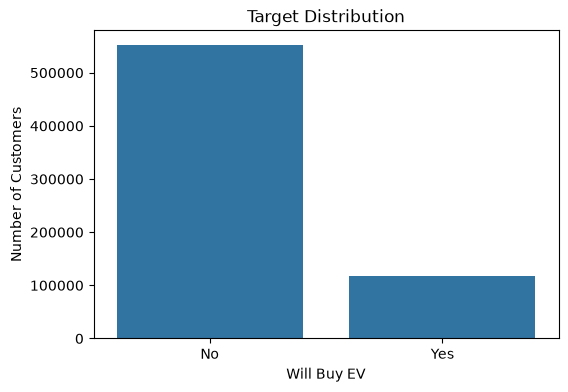

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=train,
    x="Will_Buy_EV"
)

plt.title("Target Distribution")
plt.xlabel("Will Buy EV")
plt.ylabel("Number of Customers")
plt.show()

### 1.5 Categorical Features vs Target

To understand how categorical characteristics relate to EV purchase behavior, we compare the purchase rate across each category.

In [9]:
categorical_features = categorical_cols.drop("Will_Buy_EV")

for col in categorical_features:
    purchase_rate = (
        train.groupby(col)["Will_Buy_EV"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\n{col}")
    display(purchase_rate.round(2).to_frame("Purchase Rate (%)"))


Gender


,Purchase Rate (%)
Gender,
Female,17.76
Other,17.37
Male,17.23



City_Type


,Purchase Rate (%)
City_Type,
Rural,19.34
Suburban,18.09
Urban,16.11



Current_Car_Type


...

,Purchase Rate (%)
Home_Charging_Possible,
Yes,19.58
No,12.71



Subsidy_Available


,Purchase Rate (%)
Subsidy_Available,
Yes,27.47
No,0.58



Range_Anxiety_Level


,Purchase Rate (%)
Range_Anxiety_Level,
Low,18.90
Medium,4.17
High,0.14


### 1.6 Purchase Rate by Subsidy Availability

The purchase rate varies substantially between customers with and without an available subsidy. This suggests that subsidy availability may contain strong predictive information for EV purchase intent.

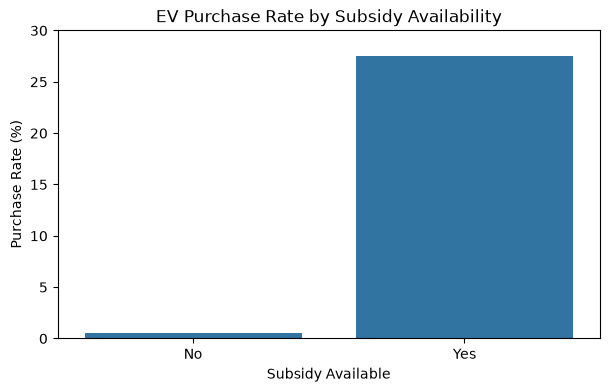

In [11]:
purchase_rate = (
    train.groupby("Subsidy_Available")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Purchase_Rate")
)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=purchase_rate,
    x="Subsidy_Available",
    y="Purchase_Rate"
)

plt.title("EV Purchase Rate by Subsidy Availability")
plt.xlabel("Subsidy Available")
plt.ylabel("Purchase Rate (%)")
plt.ylim(0, 30)

plt.show()

### 1.7 Purchase Rate by Range Anxiety Level

Range anxiety represents a customer's concern about the driving range of an electric vehicle. We examine whether purchase intent varies across different anxiety levels.

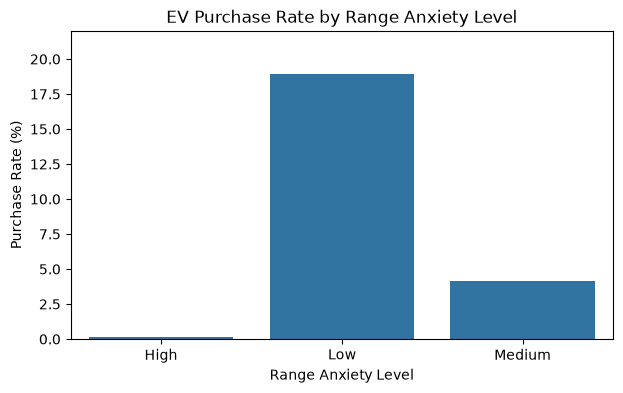

In [12]:
purchase_rate = (
    train.groupby("Range_Anxiety_Level")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Purchase_Rate")
)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=purchase_rate,
    x="Range_Anxiety_Level",
    y="Purchase_Rate"
)

plt.title("EV Purchase Rate by Range Anxiety Level")
plt.xlabel("Range Anxiety Level")
plt.ylabel("Purchase Rate (%)")
plt.ylim(0, 22)

plt.show()

### 1.8 Numerical Features vs Target

We now examine the numerical features across the target classes to identify differences in customer characteristics between EV buyers and non-buyers.

In [13]:
numerical_features = train.select_dtypes(include=["int64", "float64"]).columns.drop("id")

numerical_summary = (
    train.groupby("Will_Buy_EV")[numerical_features]
    .mean()
    .T
)

numerical_summary["Difference"] = (
    numerical_summary["Yes"] - numerical_summary["No"]
)

numerical_summary.round(2)

Will_Buy_EV,No,Yes,Difference
Age,47.08,46.83,-0.25
Annual_Income_USD,81794.59,98827.30,17032.71
Daily_Commute_km,32.55,30.29,-2.26
Number_of_Cars_Owned,1.71,1.72,0.01
Charging_Stations_Near_Home,4.99,4.82,-0.17
Charging_Stations_Near_Work,7.21,7.04,-0.17
Environmental_Concern_Level,2.63,4.38,1.75


### 1.9 Numerical Feature Distributions by Target

Mean comparisons provide an initial indication of differences between the target classes. We now visualize the distributions to identify overlap, spread, and potential nonlinear patterns.

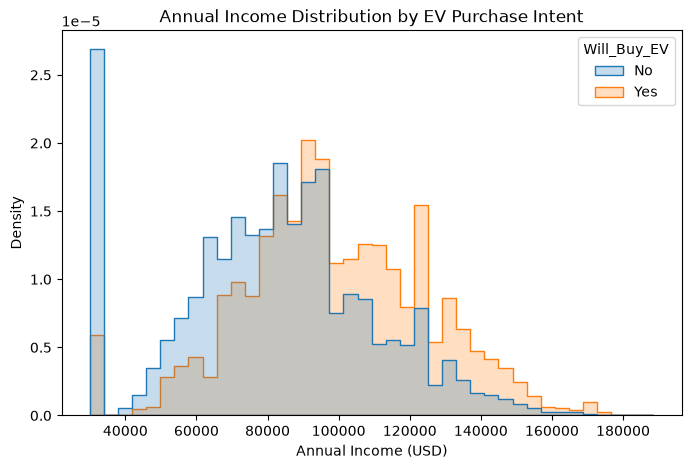

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=train,
    x="Annual_Income_USD",
    hue="Will_Buy_EV",
    bins=40,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Annual Income Distribution by EV Purchase Intent")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Density")

plt.show()

### 1.10 Environmental Concern and EV Purchase Intent

Environmental concern shows a noticeable difference between the two target classes. We visualize its distribution to examine how strongly the feature separates potential EV buyers from non-buyers.

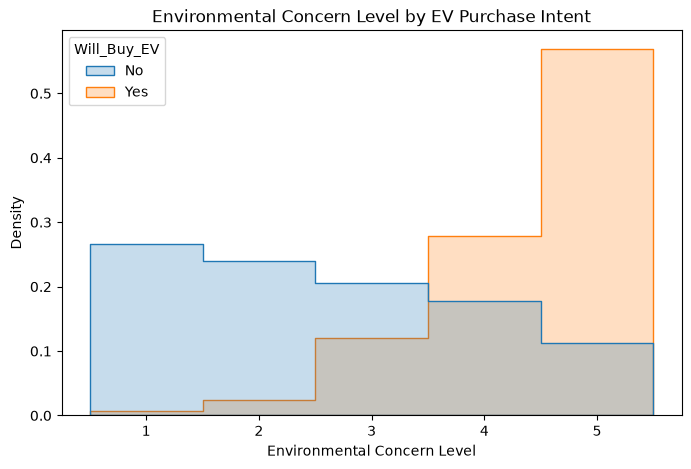

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=train,
    x="Environmental_Concern_Level",
    hue="Will_Buy_EV",
    bins=5,
    discrete=True,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Environmental Concern Level by EV Purchase Intent")
plt.xlabel("Environmental Concern Level")
plt.ylabel("Density")

plt.show()

### 1.11 Correlation Between Numerical Features

Correlation analysis helps identify linear relationships between numerical features and detect features that may contain overlapping information.

The target variable is excluded from this analysis because it is categorical at this stage.

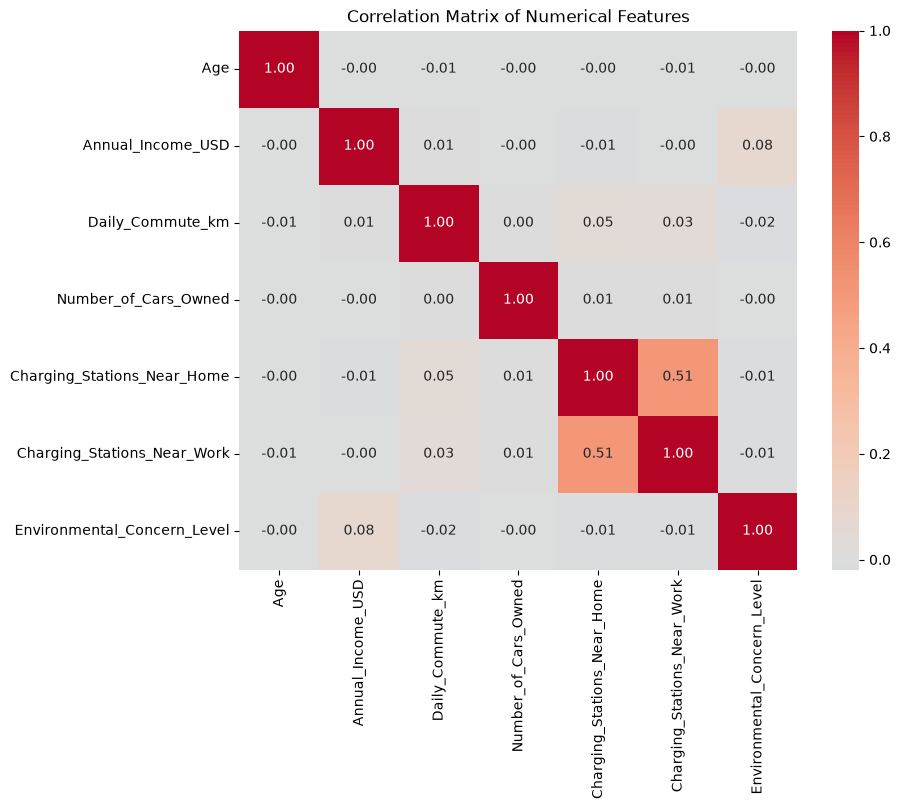

In [16]:
correlation_matrix = train[numerical_features].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

## 2. EDA Findings

The exploratory analysis provides several useful observations that will guide the modeling strategy.

### Key Observations

- The target variable is imbalanced, with approximately **82.5% non-buyers** and **17.5% potential buyers**.
- `Subsidy_Available` shows a substantial difference in EV purchase rates between its categories.
- `Range_Anxiety_Level` also shows notable differences in purchase rates across categories.
- `Environmental_Concern_Level` has a clear difference between the average values of buyers and non-buyers.
- `Annual_Income_USD` also shows a noticeable difference between the two target groups.
- `Gender`, `Number_of_Cars_Owned`, and the charging-station features show relatively smaller differences in their group-level averages.
- The `id` column is a unique identifier and will therefore not be used as a predictive feature.

### Modeling Implications

Based on these observations:

1. Categorical features will require appropriate encoding before modeling.
2. Numerical features will be evaluated using a suitable preprocessing strategy.
3. The class imbalance will be considered when designing the validation and evaluation process.
4. Since the competition uses **ROC-AUC**, model evaluation will focus on ranking ability rather than accuracy alone.
5. Feature relationships and interactions will be investigated during model development rather than relying only on individual EDA relationships.

## 3. Data Preprocessing & Validation Strategy

Before training machine learning models, the dataset must be prepared in a way that prevents data leakage and provides a reliable estimate of model performance.

Since the competition uses **ROC-AUC** as the evaluation metric, we will use a stratified validation strategy to preserve the target class distribution in both training and validation sets.

The preprocessing pipeline will include:

- Removing the identifier column
- Separating features and target
- Identifying numerical and categorical features
- Encoding categorical variables
- Applying numerical preprocessing where appropriate
- Creating a stratified train-validation split

All preprocessing steps that learn from the data will be fitted only on the training portion to avoid data leakage.

### 3.1 Separate Features and Target

The `id` column is an identifier and does not represent a meaningful customer characteristic, so it will be excluded from the model features.

The target variable `Will_Buy_EV` is separated from the input features.

In [18]:
X = train.drop(columns=["id", "Will_Buy_EV"])
y = train["Will_Buy_EV"]

X.shape, y.shape

((668665, 13), (668665,))

### 3.2 Stratified Train-Validation Split

A validation set is created to estimate model performance before submitting predictions to Kaggle.

Stratification is used to preserve the proportion of `Yes` and `No` target classes in both the training and validation sets.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((534932, 13), (133733, 13), (534932,), (133733,))

### 3.3 Identify Numerical and Categorical Features

The dataset contains both numerical and categorical features. These feature types require different preprocessing strategies before they can be used by machine learning models.

Numerical features will be handled separately from categorical features so that the preprocessing can be applied consistently to both the training and validation data.

In [20]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

Categorical features:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


### 3.4 Preprocessing Pipeline

A unified preprocessing pipeline is used to apply the appropriate transformations to each feature type.

- Numerical features will be standardized using `StandardScaler`.
- Categorical features will be converted into numerical representations using `OneHotEncoder`.
- The preprocessing steps will be fitted only on the training data and then applied to the validation data.

Using a `ColumnTransformer` keeps the preprocessing process consistent and helps prevent data leakage.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

### 3.5 Fit Preprocessing on Training Data

The preprocessing transformer is fitted only on the training data.

This ensures that statistics and category information are learned exclusively from the training set, preventing information from the validation set from influencing the preprocessing stage.

The fitted transformer is then used to transform both the training and validation data using the same learned transformations.

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

X_train_processed.shape, X_valid_processed.shape

((534932, 24), (133733, 24))

## 4. Baseline Model

Before experimenting with more complex algorithms, a baseline model is trained to establish an initial performance benchmark.

Logistic Regression is used as the first baseline because it is computationally efficient, interpretable, and provides probability estimates that can be directly evaluated using ROC-AUC.

In [23]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [24]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [25]:
from sklearn.metrics import roc_auc_score

y_valid_proba = baseline_model.predict_proba(X_valid_processed)[:, 1]

baseline_roc_auc = roc_auc_score(y_valid, y_valid_proba)

baseline_roc_auc

0.9379578769118005

In [26]:
sample_submission = pd.read_csv("../data/sample_submission.csv")

sample_submission.head(), sample_submission.shape, sample_submission.columns

(       id  Will_Buy_EV
 0  668665     0.174645
 1  668666     0.174645
 2  668667     0.174645
 3  668668     0.174645
 4  668669     0.174645,
 (286571, 2),
 Index(['id', 'Will_Buy_EV'], dtype='str'))

### 4.1 Generate Test Predictions and Submission

The baseline Logistic Regression model is used to generate purchase probabilities for the test dataset.

Since the competition evaluates predictions using ROC-AUC, the probability of the positive class (`Will_Buy_EV = Yes`) is submitted rather than hard class labels.

The predictions are stored in the required Kaggle submission format containing:

- `id` — the original test identifier
- `Will_Buy_EV` — predicted probability of purchasing an electric vehicle

The first baseline submission is saved as `submission_v1_logistic.csv` for leaderboard evaluation.

In [27]:
X_test = test.drop(columns=["id"])

X_test_processed = preprocessor.transform(X_test)

test_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

submission = pd.DataFrame({
    "id": test["id"],
    "Will_Buy_EV": test_proba
})

submission.head()

,id,Will_Buy_EV
0,668665,0.004828
1,668666,0.031922
2,668667,0.005543
3,668668,0.002703
4,668669,0.022491


In [28]:
submission_path = "../submissions/submission_v1_logistic.csv"

submission.to_csv(submission_path, index=False)

submission.shape, submission.head()

((286571, 2),
        id  Will_Buy_EV
 0  668665     0.004828
 1  668666     0.031922
 2  668667     0.005543
 3  668668     0.002703
 4  668669     0.022491)